# Classificação de Gatos

Esse é meu primeiro projeto pessoal criando uma CNN, o objetivo é regristrar meu processo de estudo, descobertas e dúvidas ao longo do caminho.

Essa é a primeira etapa de um projeto maior, meu objetivo final é criar um protótipo robotico que consiga encontrar meus gatos pela casa, brincar com eles, ou me ajudar a cuidar melhor dos bichanos.

Para isso, meu primeiro passo sera criar uma Rede Neural convolucional (CNN) capaz de distinguir meus três gatos entre eles e outros gatos.

Por possuir um conjunto de dados pequeno, vou para aplicar conceitos de Transfer Learning e usar um modelo pré-treinado (EfficientNet-B0).

## Objetos de Estudo

### MoonCake

* Pelagem: Branca.
* Pelo: Longo.
* Olhos: Azuis.


### Francisco

* Pelagem: Rajada.
* Pelo: Curto.
* Olhos: Verdes.

### Pedrolino

* Pelagem: Frajola.
* Pelo: Curto.
* Olhos: Variação entre verde e amarelo.

## Pré processamento

Comecei criando o dataset contendo

* 150 fotos do MoonCake.
* 150 fotos do Francisco.
* 150 fotos do Pedrolino.
* 200 fotos de gatos variados.

A primeira etapa, antes de começar a contruir a rede neural, é realizar o pré-processamento das imagens, padronizando, recortando, convertendo em matrizes matemáticas e por fim, ajustando as cores.

Para isso vou usar o `torchvision`, ele é uma biblioteca do PyTorch, focada em tarefas de visão computacional.

In [ ]:
# conexão com o drive para extrair o dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# pré processamento
transformacoes = transforms.Compose([
    transforms.Resize(256), # padroniza o menor lado para 256 pixels
    transforms.CenterCrop(224), # recorta um quadrado de 224x224 no centro da imagem
    transforms.ToTensor(), # converte a imagem em matrizes matemáticas
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ajusta as cores para o padrão da rede
])

# aponto o pytorch para a pasta do drive, ele lê as subpastas e entende cada uma como um gato diferente
caminho_dataset = "/content/drive/MyDrive/Dados_Exploratorios/cnn/classificacao-gatos"
meu_dataset = datasets.ImageFolder(root=caminho_dataset, transform=transformacoes)

O pré processamento é uma etapa muito importante no treinamento dos modelos, ele padroniza e aprimora os dados para que a rede consiga trabalhar de forma eficaz, precisa e rápida.

## Separação dos Dados

A separação entre os dados de treinamento e os dados de validação é fundamental para garantir que o modelo realmente aprendeu, e não apenas decorou os dados (overfitting).

Vou utilizar a prática padrão de 80% dos dados para treinamento, e 20% para o teste.

A separação é feita de forma aleatória, garantindo que as distribuições de classes sejam semelhantes entre os conjuntos. Como o dataset é pequeno, a validação ajudará a monitorar overfitting durante o fine-tuning.

In [ ]:
from torch.utils.data import random_split

# Estou fixiando uma semente, para garantir que a divisão seja sempre a mesma
torch.manual_seed(42)

# 80% treino, 20% validação
tamanho_total = len(meu_dataset)
tamanho_treino = int(0.8 * tamanho_total)
tamanho_validacao = tamanho_total - tamanho_treino

# Separação aleatoria
treino_dataset, validacao_dataset = random_split(meu_dataset, [tamanho_treino, tamanho_validacao])

print(f"Tamanho de imagens carregadas: {tamanho_total}")
print(f"Tamanho de imagens de treino: {len(treino_dataset)}")
print(f"Tamanho de imagens de validação: {len(validacao_dataset)}")

Tamanho de imagens carregadas: 587
Tamanho de imagens de treino: 469
Tamanho de imagens de validação: 118


## DataLoaders

É muito custoso para a GPU uma rede neural que processa todo dataset de uma vez. Portanto, os dados serão processados em lotes pequenos.

Vou usar o DataLoader para dividir o dataset em lotes pequenos de 32, e tambem, embaralhar as imagens de treino (shuffle=True) a cada ciclo, garantindo que a rede não aprenda a ordem das imagens.

In [ ]:
batch_size = 32

train_loader = DataLoader(treino_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(validacao_dataset, batch_size=batch_size, shuffle=False)

print(f"Tamanho do loader de treino: {len(train_loader)}")
print(f"Tamanho do loader de validação: {len(val_loader)}")

Tamanho do loader de treino: 15
Tamanho do loader de validação: 4


## Arquitetura EfficientNet

Para iniciar, vou utilizar a arquitetura EfficientNet, usando seu menor e mais rápido modelo, o B0. Tal arquitetura foi projetada para ser extremamente eficiente e precisa, o que é ideal para este projeto de classificação.

O modelo `efficientnet_b0` ja vem com pesos pré treinados, então ele tem conhecimentos sobre formas e texturas. Isso é muito positivo para o projeto pois estou trabalhando com um dataset pequeno.

In [ ]:
import timm
import torch.nn as nn

modelo = timm.create_model('efficientnet_b0', pretrained=True)

# Congelando todos os parâmetros da base, preservando o que rede já sabe.
for param in modelo.parameters():
    param.requires_grad = False

# Quantidade de entredas do classificador
n_features = modelo.classifier.in_features

# Estou colocando uma nova camada linear, com número de saídas 4 (Mooncake, Francisco, Pedrolino, Desconhecidos).
modelo.classifier = nn.Linear(n_features, 4)

# A variavel device vai mapear o hardware disponivel, selecionando a placa de video cuda ou a cpu.
print(f"CUDA disponível: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device selecionado: {device}")
modelo = modelo.to(device)

print(f"Modelo configurado para rodar em: {device}")
print(f"Arquitetura: EfficientNet-B0 | Classes de saída: {modelo.classifier.out_features}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

CUDA disponível: True
Device selecionado: cuda
Modelo configurado para rodar em: cuda
Arquitetura: EfficientNet-B0 | Classes de saída: 4


NOTA: Esta é uma abordagem de feature extraction: congelamos a base pré-treinada e treinamos apenas a camada final. Mais adiante, testarei fine-tuning parcial e total.

# Função de Perda e Otimizador

Para esse modelo vou usar a função de perda `CrossEntropyLoss`, ela é ideal para problemas onde o modelo precisa escolher entre classes diferentes. Ela irá receber as probabilidades que a rede gerou e as comparar com o gabarito. Quanto maior a distância entre essas duas métricas, maior será o valor de perda.

O otimizador usado será o `Adam`, com uma taxa de aprendizado de 0.001, ele é o responsável por ajustar os pesos da última camada, preparando a rede para próxima tentativa. Como congelamos a base do EfficientNet, o otimizador só vai atuar nos parâmetros da nova camada `modelo.classifier`.

In [ ]:
import torch.optim as optim

# Função de Perda
criterion = nn.CrossEntropyLoss()

# Otimizador
optimizer = optim.Adam(modelo.classifier.parameters(), lr=0.001)

print("Configuração de treinamento concluída:")
print(f"Função de Perda: {criterion.__class__.__name__}")
print(f"Otimizador: {optimizer.__class__.__name__}")

Configuração de treinamento concluída:
Função de Perda: CrossEntropyLoss
Otimizador: Adam


## Loop de Treinamento

O aprendizado acontece durante o loop de treinamento. De forma resumida, o modelo gera previsões, calcula o erro, identifica quais pesos contribuíram mais para o erro (backpropagation) e os ajusta (otimizador). Esse ciclo se repete para cada lote de imagens. Aqui, o processo completo será repetido 20 vezes (épocas) sobre todo o conjunto de treino.

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

epochs = 20
melhor_acc_val = 0.0

historico_train_loss = []
historico_val_loss = []
historico_train_acc = []
historico_val_acc = []

print("Iniciando o treinamento...")

for epoch in range(epochs):
    inicio_epoca = time.time()

    # --- Fase de treino ---
    modelo.train()
    train_loss_acum = 0.0
    train_acertos = 0
    train_total = 0

    for imagens, rotulos in train_loader:
        imagens, rotulos = imagens.to(device), rotulos.to(device) # Move dados para GPU/CPU

        optimizer.zero_grad()  # Zera gradientes da iteração anterior
        saidas = modelo(imagens) # Previsões
        loss = criterion(saidas, rotulos) # Calcula o erro
        loss.backward() # Calcula gradientes
        optimizer.step() # Atualiza os pesos

        # Acumula métricas para calcular médias no final da época
        train_loss_acum += loss.item() * imagens.size(0)
        _, preditos = torch.max(saidas, 1)
        train_acertos += (preditos == rotulos).sum().item()
        train_total += rotulos.size(0)

    epoch_train_loss = train_loss_acum / train_total
    epoch_train_acc = train_acertos / train_total

    # --- Fase de validação ---
    modelo.eval()
    val_loss_acum = 0.0
    val_acertos = 0
    val_total = 0

    with torch.no_grad():
        for imagens, rotulos in val_loader:
            imagens, rotulos = imagens.to(device), rotulos.to(device)
            saidas = modelo(imagens)
            loss = criterion(saidas, rotulos)

            val_loss_acum += loss.item() * imagens.size(0)
            _, preditos = torch.max(saidas, 1)
            val_acertos += (preditos == rotulos).sum().item()
            val_total += rotulos.size(0)

    epoch_val_loss = val_loss_acum / val_total
    epoch_val_acc = val_acertos / val_total

    # Armazenar histórico
    historico_train_loss.append(epoch_train_loss)
    historico_train_acc.append(epoch_train_acc)
    historico_val_loss.append(epoch_val_loss)
    historico_val_acc.append(epoch_val_acc)

    # Salvar melhor modelo
    if epoch_val_acc > melhor_acc_val:
        melhor_acc_val = epoch_val_acc
        torch.save(modelo.state_dict(), 'melhor_modelo.pth')
        print(f"  >>> Melhor modelo salvo com acc val = {epoch_val_acc:.4f}")

    # Salvar no Drive
    !cp melhor_modelo.pth "/content/drive/MyDrive/Dados_Exploratorios/cnn/melhor_modelo.pth"

    tempo_epoca = time.time() - inicio_epoca
    print(f"Época {epoch+1:2d}/{epochs} [{tempo_epoca:.1f}s]")
    print(f"  Treino - Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.4f}")
    print(f"  Val    - Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.4f}\n")

print("Treinamento concluído!")

Iniciando o treinamento...
  >>> Melhor modelo salvo com acc val = 0.8644
Época  1/20 [535.3s]
  Treino - Loss: 1.1241 | Acc: 0.5821
  Val    - Loss: 0.7862 | Acc: 0.8644

  >>> Melhor modelo salvo com acc val = 0.9068
Época  2/20 [49.3s]
  Treino - Loss: 0.6838 | Acc: 0.8785
  Val    - Loss: 0.5634 | Acc: 0.9068

  >>> Melhor modelo salvo com acc val = 0.9237
Época  3/20 [48.6s]
  Treino - Loss: 0.4607 | Acc: 0.9382
  Val    - Loss: 0.4589 | Acc: 0.9237

Época  4/20 [49.5s]
  Treino - Loss: 0.3779 | Acc: 0.9190
  Val    - Loss: 0.3992 | Acc: 0.9068

Época  5/20 [48.5s]
  Treino - Loss: 0.3108 | Acc: 0.9446
  Val    - Loss: 0.3619 | Acc: 0.9153

  >>> Melhor modelo salvo com acc val = 0.9407
Época  6/20 [49.8s]
  Treino - Loss: 0.2578 | Acc: 0.9638
  Val    - Loss: 0.3171 | Acc: 0.9407

Época  7/20 [48.6s]
  Treino - Loss: 0.2389 | Acc: 0.9680
  Val    - Loss: 0.2966 | Acc: 0.9237

Época  8/20 [49.7s]
  Treino - Loss: 0.2068 | Acc: 0.9701
  Val    - Loss: 0.2788 | Acc: 0.9322

Época  9

### Carrega o Modelo Salvo

In [ ]:
import torch
import timm
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recriar a arquitetura usada no treinamento
modelo = timm.create_model('efficientnet_b0', pretrained=False)
n_features = modelo.classifier.in_features
modelo.classifier = nn.Linear(n_features, 4)   # 4 classes
modelo = modelo.to(device)

# Carregar os pesos salvos
caminho_drive = "/content/drive/MyDrive/Dados_Exploratorios/cnn/melhor_modelo.pth"
modelo.load_state_dict(torch.load(caminho_drive, map_location=device))
modelo.eval()
print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


## Gráfico

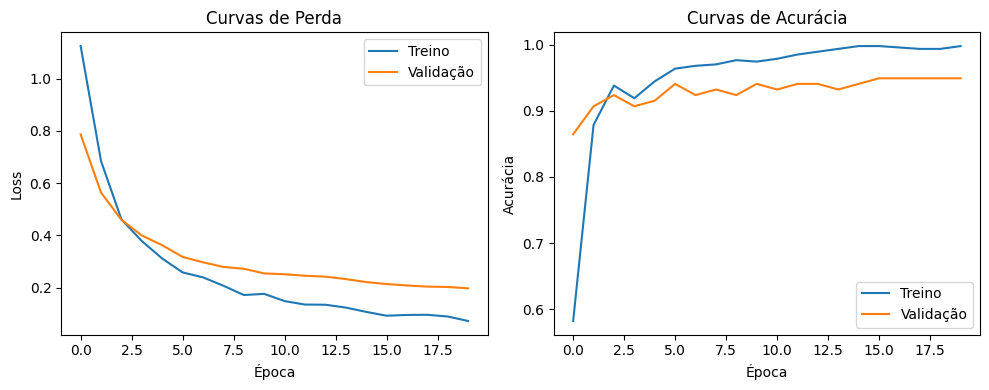

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(historico_train_loss, label='Treino')
plt.plot(historico_val_loss, label='Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Curvas de Perda')

plt.subplot(1,2,2)
plt.plot(historico_train_acc, label='Treino')
plt.plot(historico_val_acc, label='Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.title('Curvas de Acurácia')
plt.tight_layout()
plt.show()

## Matriz de confusão

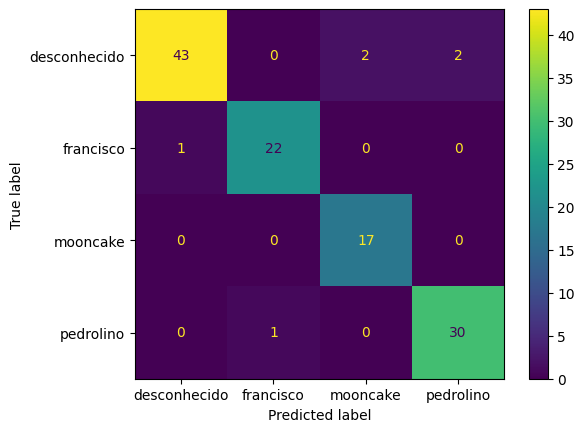

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Coletar previsões do melhor modelo
modelo.load_state_dict(torch.load('melhor_modelo.pth'))
modelo.eval()

todos_pred = []
todos_rotulos = []
with torch.no_grad():
    for imagens, rotulos in val_loader:
        imagens = imagens.to(device)
        saidas = modelo(imagens)
        _, pred = torch.max(saidas, 1)
        todos_pred.extend(pred.cpu().numpy())
        todos_rotulos.extend(rotulos.numpy())

cm = confusion_matrix(todos_rotulos, todos_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=meu_dataset.classes)
disp.plot()
plt.show()

# Versão com Aumento de Dados

Como dito anteriormente, a quantidade de dados disponiveis é muito pequena. Por esse motivo, irei testar uma segunda versão usando tecnicas para criar dados sinteticos que iram aumentar e diversificar meu conjunto.

Selecionei três tecnicas distintas:

* RandomHorizontalFlip
* ColorJitter
* RandomRotation

O uso de tais métodos, por consequência, ajudam a melhorar a otimização e generalização do modelo, diminuindo o overfitting.

Apos o treinamento, irei realizar a análise comparativa dos dois modelos e comparar seus desempenho.


In [ ]:
####